# Discrete Fourier Series (DFS) — Manual Implementation (No FFT)

**Course:** Signals / DSP  
**Homework:** DFS by correlation / inner products (`np.sum` / `np.dot`)  
**Student:** Equipo 2: Espinoza Matamoros Percival Ulises, Garcìa Cortes Adolfo de Jesus, Lugo Manzano Rodrigo

**Date:** 7 de Octubre del 2026

---

## Objective

Implement the **Discrete Fourier Series (DFS)** for **periodic discrete-time** signals.

You must:

1. Construct **three** periodic discrete signals (one period only).
2. Compute DFS coefficients **manually** using the definition (correlation / inner product).
3. Reconstruct each signal from its coefficients.
4. Compare original vs reconstructed signals.
5. Report reconstruction error.

---

## Restrictions (IMPORTANT)

 Allowed:
- `numpy`, `matplotlib`
- `np.sum`, `np.dot`
- `np.exp`, complex numbers, loops (if you want)

 Not allowed:
- `np.fft.fft`, `np.fft.ifft`, or any FFT/DFT helper
- Any library function that directly returns Fourier coefficients


## DFS Definitions (use these)

We work with one period of a discrete-time periodic signal:
- Period: $$N$$
- Samples: $$n = 0,1,\dots,N-1$$
- Signal values: $$x[n]$$

### Complex exponential basis
$$
\phi_k[n] = e^{j\frac{2\pi}{N}kn},\quad k=0,1,\dots,N-1
$$

### Analysis (coefficients)
$$
X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\;e^{-j\frac{2\pi}{N}kn}
$$

### Synthesis (reconstruction)
$$
\hat{x}[n] = \sum_{k=0}^{N-1} X[k]\;e^{j\frac{2\pi}{N}kn}
$$

### Reconstruction error (RMSE)
$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

**Implementation requirement:** compute the sums using `np.sum` or `np.dot`.


In [76]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)

np.random.seed(0)


## Deliverables (what you must submit)

For each of the three signals (A, B, C), include:

1) A plot of the signal over one period: $$x[n]$$, $$n=0..N-1$$  
2) A stem/bar plot of the magnitude spectrum: $$|X[k]|$$  
3) A plot of the phase spectrum: $$angle X[k]$$  
4) A plot comparing $$x[n]$$ and $$\hat{x}[n]$$ over one period  
5) RMSE value and 2–4 sentences of interpretation

---

## Signals to analyze

You must implement all DFS for **three different periods**:
N1 = 16
N2 = 32
N3 = 64

### Signal A — Square wave
One period definition:
- $$x_A[n] = 1$$ for $$0 \le n < N_1/2$$
- $$x_A[n] = -1$$ for $$N_1/2 \le n < N_1$$

### Signal B — Triangle wave
Build a discrete triangle over one period, peak amplitude 1 (or rescale to $[-1,1]$).

### Signal C — Sum of sinusoids
$$
x_C[n] =
0.8\cos\left(2\pi\frac{1}{N}n\right)
+ 0.4\sin\left(2\pi\frac{2}{N}n + 0.3\right)
+ 0.2\cos\left(2\pi\frac{3}{N}n - 0.8\right)
$$

In [77]:
# === TODO 1: DFS (Analysis) ===
def dfs(x):
    x = np.asarray(x)
    N = len(x)
    n = np.arange(N)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
     
        X[k] = (1.0 / N) * np.sum(x * np.exp(-1j * 2 * np.pi * k * n / N))
    return X


# === TODO 2: Inverse DFS (Synthesis) ===
def idfs(X):
    X = np.asarray(X)
    N = len(X)
    k = np.arange(N)
    x_hat = np.zeros(N, dtype=complex)
    for n in range(N):
       
        x_hat[n] = np.sum(X * np.exp(1j * 2 * np.pi * k * n / N))
    return x_hat


def rmse(x, x_hat):
    x = np.asarray(x)
    x_hat = np.asarray(x_hat)
    N = len(x)
    return np.sqrt((1.0 / N) * np.sum(np.abs(x - x_hat) ** 2))

def fase(X, tol=1e-10):
    # fase = 0 donde |X| ≈ 0 (ahí el ángulo no está definido)
    return np.where(np.abs(X) > tol, np.angle(X), 0.0)


---

# Construcción y análisis de las señales A, B y C

En esta sección juntamos el construir cada señal y correr el análisis. En lugar de ejecutar todo con `analyze_signal` al final, analizamos cada señal paso a paso, para poder visualizarlas mejor, siguiendo los entregables de la plantilla:

1. Señal en el tiempo $x[n]$
2. Espectro de magnitud $|X[k]|$
3. Espectro de fase $\angle X[k]$
4. Reconstrucción $\hat{x}[n]$ vs. $x[n]$
5. RMSE

Periodos usados: $N_1 = 16$, $N_2 = 32$, $N_3 = 64$ (los del enunciado).

---

# Señal A — Onda cuadrada

**Signal A — Square wave.** One period definition:
- $x_A[n] = 1$ para $0 \le n < N_1/2$
- $x_A[n] = -1$ para $N_1/2 \le n < N_1$

Periodo: $N_1 = 16$.

### Construcción de la señal A

Definimos el eje de muestras $n$, el eje de frecuencias $k$ y la señal $x_A[n]$ para un periodo.
El bloque con `kimp` y `XA_teo` comprueba que nuestro `dfs` es correcto antes de graficar.

In [78]:
# Señal A, cuadrada, N1 = 16
N1 = 16
n1 = np.arange(N1)
k1 = np.arange(N1)

xA = np.where(n1 < N1 // 2, 1.0, -1.0)

kimp = np.arange(1, N1, 2)
XA_teo = np.zeros(N1, dtype=complex)
XA_teo[kimp] = (1/8) * (1 - 1j/np.tan(np.pi*kimp/16))
print("A: error vs fórmula =", np.max(np.abs(xA - XA_teo)))

A: error vs fórmula = 1.2886168843054175


### Inciso a) Gráfica de $x_A[n]$ en un periodo

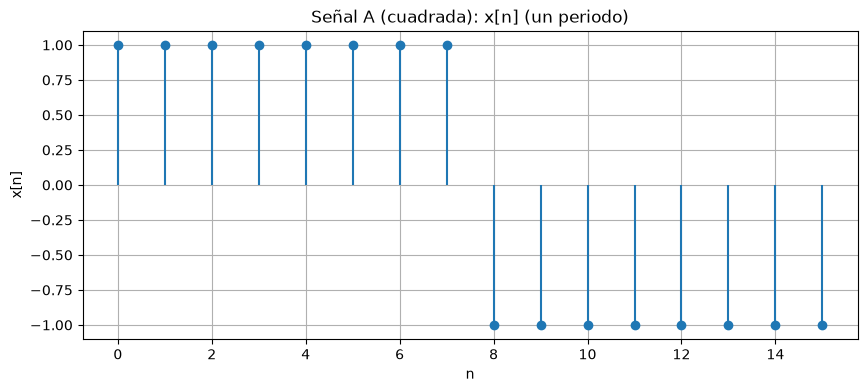

In [79]:
plt.figure()
plt.stem(n1, xA, basefmt=" ")
plt.title("Señal A (cuadrada): x[n] (un periodo)")
plt.xlabel("n"); plt.ylabel("x[n]")
plt.grid(True)
plt.show()


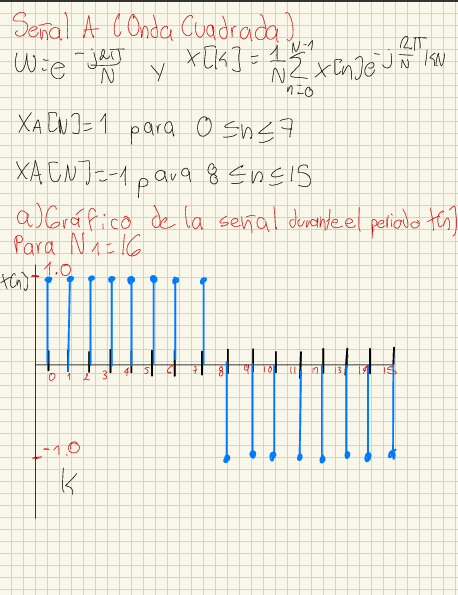



### Inciso b) Espectro de magnitud $|X_A[k]|$

Calculamos los coeficientes con `dfs` (producto interno de $x_A[n]$ con $e^{-j\frac{2\pi}{N}kn}$) y graficamos su magnitud.
Además se verifica el **teorema de Parseval**: la potencia de la señal en el tiempo debe ser igual a la suma de $|X[k]|^2$ en frecuencia, es decir $\sum_k |X[k]|^2 = \frac{1}{N}\sum_n |x[n]|^2$.

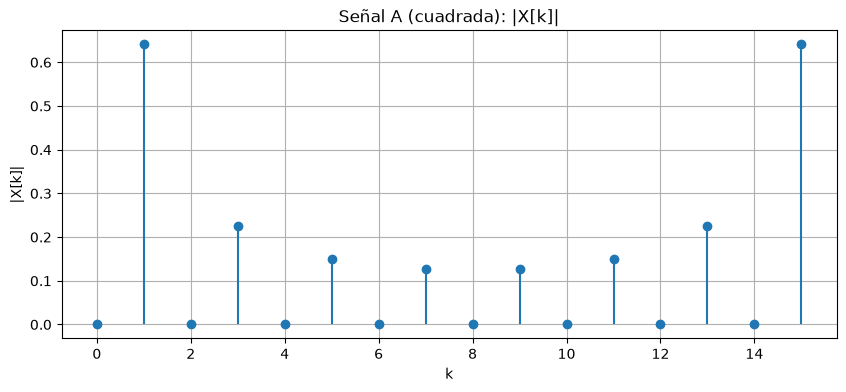

Parseval: 0.9999999999999986 vs 1.0


In [80]:
XA = dfs(xA)

plt.figure()
plt.stem(k1, np.abs(XA), basefmt=" ")
plt.title("Señal A (cuadrada): |X[k]|")
plt.xlabel("k"); plt.ylabel("|X[k]|")
plt.grid(True)
plt.show()

print("Parseval:", np.sum(np.abs(XA)**2), "vs", np.mean(xA**2))

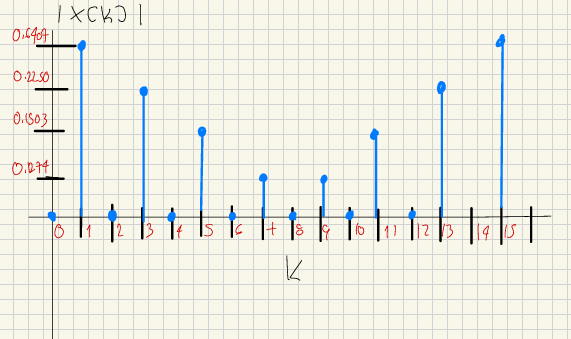

### Inciso c) Espectro de fase $\angle X_A[k]$

Usamos `fase()`: es `np.angle(X)` pero con 0 donde $|X[k]| \approx 0$, porque ahí el ángulo no está definido y solo se vería ruido.

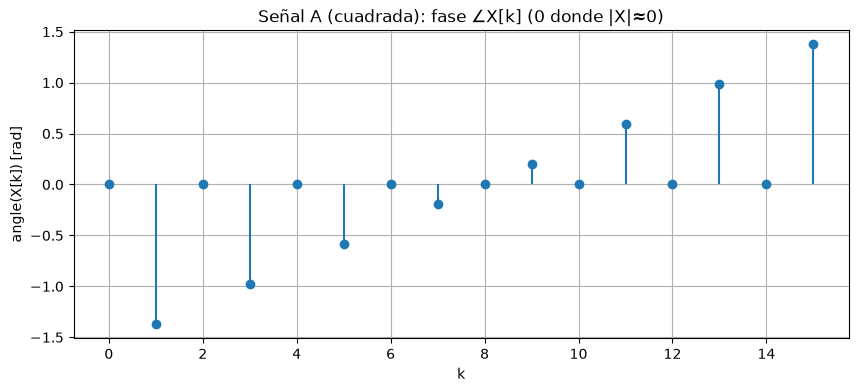

In [81]:
plt.figure()
plt.stem(k1, fase(XA), basefmt=" ")
plt.title("Señal A (cuadrada): fase ∠X[k] (0 donde |X|≈0)")
plt.xlabel("k"); plt.ylabel("angle(X[k]) [rad]")
plt.grid(True)
plt.show()

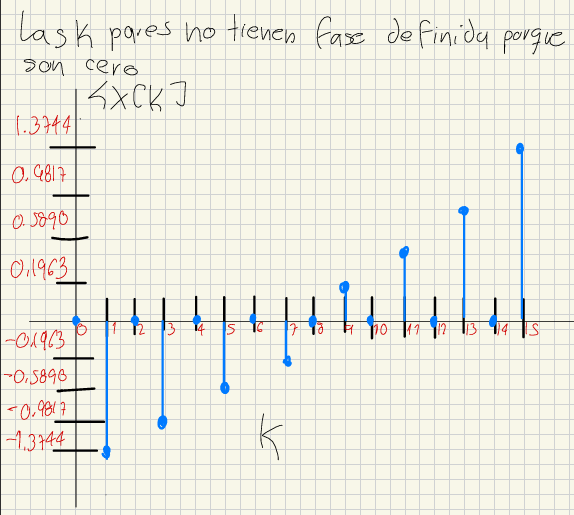

### Inciso d) Reconstrucción $\hat{x}_A[n]$ vs. $x_A[n]$

Reconstruimos la señal con `idfs` (síntesis) y la comparamos con la original sobre un periodo. Se grafica `np.real(x_hat)` porque la parte imaginaria es solo ruido numérico.

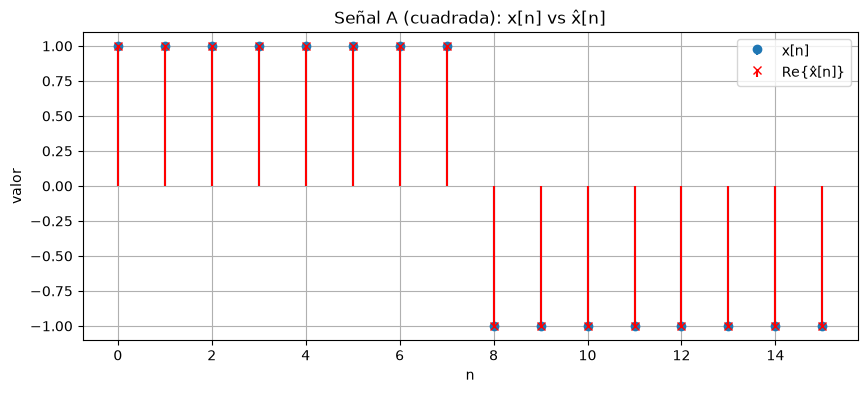

In [82]:
xA_hat = idfs(XA)

plt.figure()
plt.stem(n1, np.real(xA), basefmt=" ", markerfmt="o", label="x[n]")
plt.stem(n1, np.real(xA_hat), basefmt=" ", markerfmt="x", linefmt="r-", label="Re{x̂[n]}")
plt.title("Señal A (cuadrada): x[n] vs x̂[n]")
plt.xlabel("n"); plt.ylabel("valor")
plt.grid(True)
plt.legend()
plt.show()

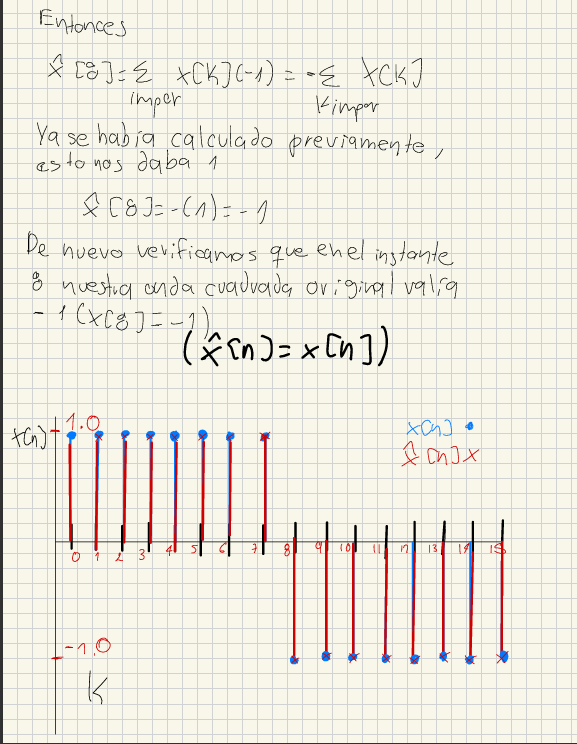

### Inciso e) Error de reconstrucción (RMSE)

Error cuadrático medio sobre un periodo:

$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

**¿Por qué se imprime la parte imaginaria máxima de $\hat{x}[n]$?** Como `idfs` suma exponenciales complejas, así que $\hat{x}[n]$ sale como número complejo aunque $x[n]$ sea real. En teoría su parte imaginaria es exactamente 0 (los términos de $k$ y $N-k$ son conjugados y se cancelan), pero por el redondeo de la computadora queda un residuo muy pequeño. La línea `np.max(np.abs(np.imag(xA_hat)))` busca el mayor de esos residuos: si es del orden de $10^{-15}$ la precisión numérica, es solo ruido y no información de la señal. Por eso es válido comparar $x[n]$ con `np.real(xA_hat)` (como en el inciso d) y, como pide la plantilla, reportar que se tomó la parte real.

In [83]:
eA = rmse(xA, xA_hat)
print(f"Señal A: N={N1}, RMSE = {eA:.6e}")
print(f"Máx |Im{{x̂[n]}}| = {np.max(np.abs(np.imag(xA_hat))):.3e}  (se tomó la parte real)")

Señal A: N=16, RMSE = 3.141595e-15
Máx |Im{x̂[n]}| = 5.218e-15  (se tomó la parte real)


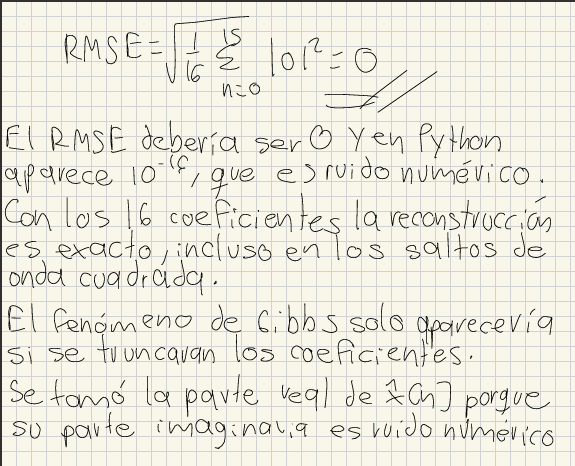

---

# Señal B — Onda triangular

**Signal B — Triangle wave.** Build a discrete triangle over one period, peak amplitude 1 (or rescale to $[-1,1]$).

Periodo: $N_2 = 32$.

### Construcción de la señal B

Definimos el eje de muestras $n$, el eje de frecuencias $k$ y la señal $x_B[n]$ para un periodo. La triangular se reescala a $[-1,1]$: vale $-1$ en $n=0$, sube hasta $+1$ en $n = N_2/2$ y vuelve a bajar.

Igual que en la señal A, el bloque con `kimp` y `XB_teo` comprueba que `dfs` es correcto.

In [84]:
# Señal B, triangular, N2 = 32
N2 = 32
n2 = np.arange(N2)
k2 = np.arange(N2)

xB = 1 - 4*np.abs(n2 - N2/2)/N2

kimp = np.arange(1, N2, 2)
XB_teo = np.zeros(N2, dtype=complex)
XB_teo[kimp] = -4 / (N2**2 * np.sin(np.pi*kimp/N2)**2)
print("B: error vs fórmula =", np.max(np.abs(xB - XB_teo)))

B: error vs fórmula = 1.0


### Inciso a) Gráfica de $x_B[n]$ en un periodo

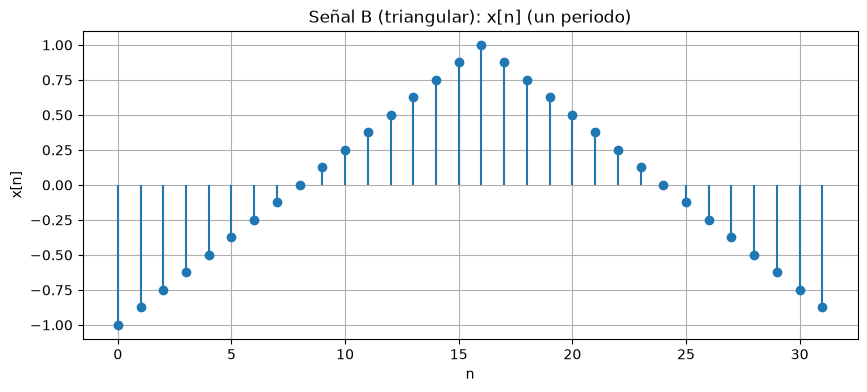

In [85]:
plt.figure()
plt.stem(n2, xB, basefmt=" ")
plt.title("Señal B (triangular): x[n] (un periodo)")
plt.xlabel("n"); plt.ylabel("x[n]")
plt.grid(True)
plt.show()

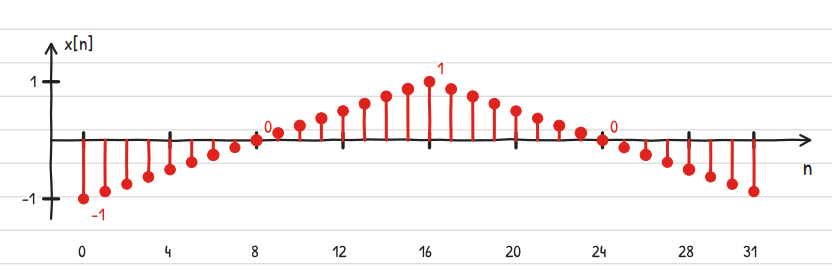

### Inciso b) Espectro de magnitud $|X_B[k]|$

Calculamos los coeficientes con `dfs` (producto interno de $x_B[n]$ con $e^{-j\frac{2\pi}{N}kn}$) y graficamos su magnitud.
Igual que en la señal A, se verifica el teorema de Parseval. El `print` compara ambos lados (`np.sum(np.abs(XB)**2)` contra `np.mean(xB**2)`), si coinciden, el DFS conserva la energía de la señal.

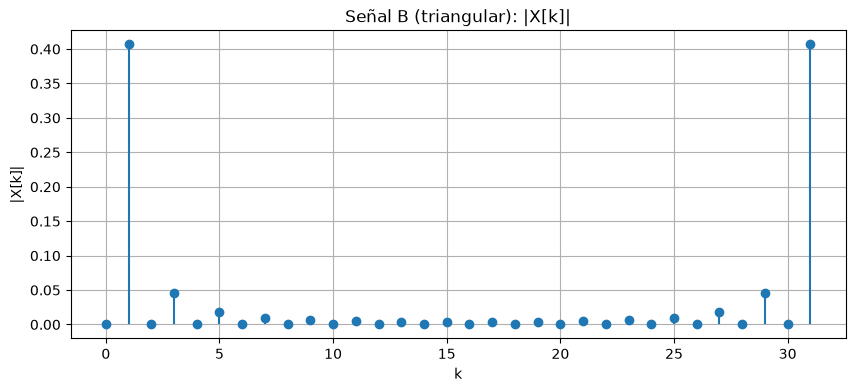

Parseval: 0.33593750000000033 vs 0.3359375


In [86]:
XB = dfs(xB)

plt.figure()
plt.stem(k2, np.abs(XB), basefmt=" ")
plt.title("Señal B (triangular): |X[k]|")
plt.xlabel("k"); plt.ylabel("|X[k]|")
plt.grid(True)
plt.show()

print("Parseval:", np.sum(np.abs(XB)**2), "vs", np.mean(xB**2))

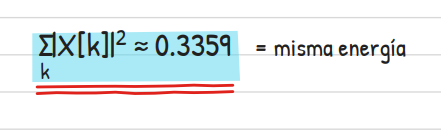

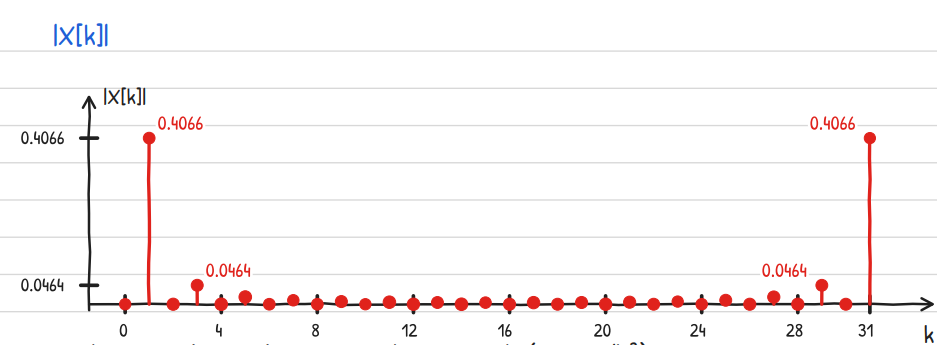

### Inciso c) Espectro de fase $\angle X_B[k]$

Usamos `fase()`: es `np.angle(X)` pero con 0 donde $|X[k]| \approx 0$, porque ahí el ángulo no está definido y solo se vería ruido.

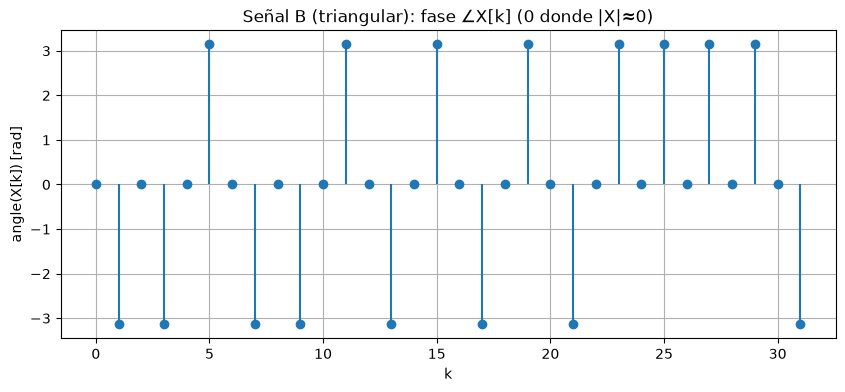

In [87]:
plt.figure()
plt.stem(k2, fase(XB), basefmt=" ")
plt.title("Señal B (triangular): fase ∠X[k] (0 donde |X|≈0)")
plt.xlabel("k"); plt.ylabel("angle(X[k]) [rad]")
plt.grid(True)
plt.show()

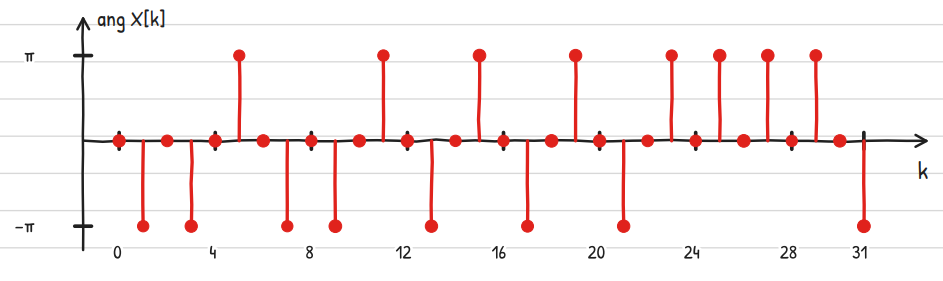

### Inciso d) Reconstrucción $\hat{x}_B[n]$ vs. $x_B[n]$

Reconstruimos la señal con `idfs` (síntesis) y la comparamos con la original sobre un periodo. Se grafica `np.real(x_hat)` porque la parte imaginaria es solo ruido numérico.

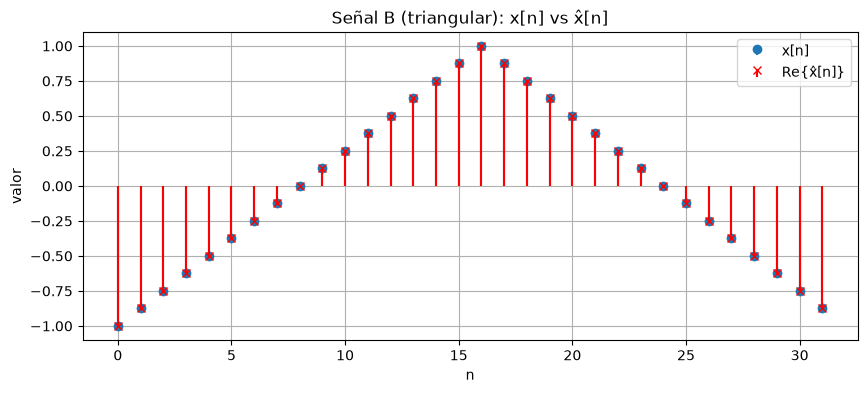

In [88]:
xB_hat = idfs(XB)

plt.figure()
plt.stem(n2, np.real(xB), basefmt=" ", markerfmt="o", label="x[n]")
plt.stem(n2, np.real(xB_hat), basefmt=" ", markerfmt="x", linefmt="r-", label="Re{x̂[n]}")
plt.title("Señal B (triangular): x[n] vs x̂[n]")
plt.xlabel("n"); plt.ylabel("valor")
plt.grid(True)
plt.legend()
plt.show()

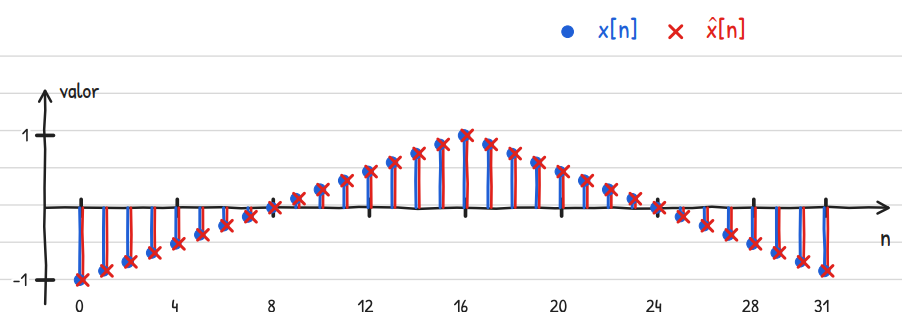

### Inciso e) Error de reconstrucción (RMSE)

Error cuadrático medio sobre un periodo:

$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

Igual que en la señal A, se imprime la parte imaginaria máxima de $\hat{x}[n]$ (`np.max(np.abs(np.imag(xB_hat)))`): como $x_B[n]$ es real, en teoría vale 0 y lo que queda es redondeo numérico (del orden de $10^{-15}$ a $10^{-14}$).

In [89]:
eB = rmse(xB, xB_hat)
print(f"Señal B: N={N2}, RMSE = {eB:.6e}")
print(f"Máx |Im{{x̂[n]}}| = {np.max(np.abs(np.imag(xB_hat))):.3e}  (se tomó la parte real)")

Señal B: N=32, RMSE = 2.795102e-15
Máx |Im{x̂[n]}| = 4.344e-15  (se tomó la parte real)


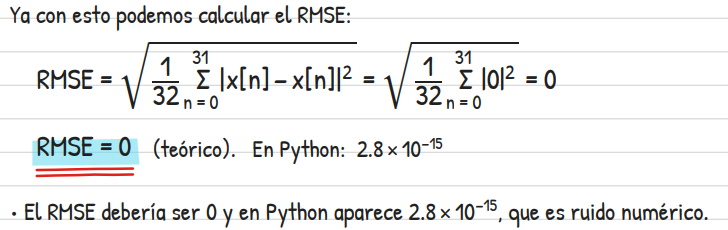

---

# Señal C — Suma de sinusoides

**Signal C — Sum of sinusoids**

$$
x_C[n] =
0.8\cos\left(2\pi\frac{1}{N}n\right)
+ 0.4\sin\left(2\pi\frac{2}{N}n + 0.3\right)
+ 0.2\cos\left(2\pi\frac{3}{N}n - 0.8\right)
$$

Periodo: $N_3 = 64$.

### Construcción de la señal C

Definimos el eje de muestras $n$, el eje de frecuencias $k$ y la señal $x_C[n]$ para un periodo.

El bloque con `XC_teo` comprueba que `dfs` es correcto. Un término $A\cos\left(\frac{2\pi}{N}kn + \varphi\right)$ aporta $\frac{A}{2}e^{j\varphi}$ en el índice $k$ y $\frac{A}{2}e^{-j\varphi}$ en $N-k$. El seno se convierte a coseno restando $\frac{\pi}{2}$ a la fase, por eso el segundo término usa $\varphi_2 = 0.3 - \frac{\pi}{2}$. Así, `XC_teo` solo tiene valores distintos de cero en $k = 1, 2, 3$ y $N-1, N-2, N-3$, con magnitudes $0.4$, $0.2$ y $0.1$. El `print` muestra la diferencia máxima respecto al DFS calculado: un valor del orden de $10^{-15}$ significa que coinciden.

In [90]:
# Señal C, suma de sinusoides, N3 = 64
N3 = 64
n3 = np.arange(N3)
k3 = np.arange(N3)

xC = (0.8*np.cos(2*np.pi*1/N3*n3)
      + 0.4*np.sin(2*np.pi*2/N3*n3 + 0.3)
      + 0.2*np.cos(2*np.pi*3/N3*n3 - 0.8))

XC_teo = np.zeros(N3, dtype=complex)
XC_teo[1] = 0.4;  XC_teo[N3-1] = 0.4
phi2 = 0.3 - np.pi/2
XC_teo[2] = 0.2*np.exp(1j*phi2);  XC_teo[N3-2] = 0.2*np.exp(-1j*phi2)
XC_teo[3] = 0.1*np.exp(-1j*0.8);  XC_teo[N3-3] = 0.1*np.exp(1j*0.8)
print("C: error vs fórmula =", np.max(np.abs(xC - XC_teo)))

C: error vs fórmula = 1.2787730717202757


### Inciso a) Gráfica de $x_C[n]$ en un periodo

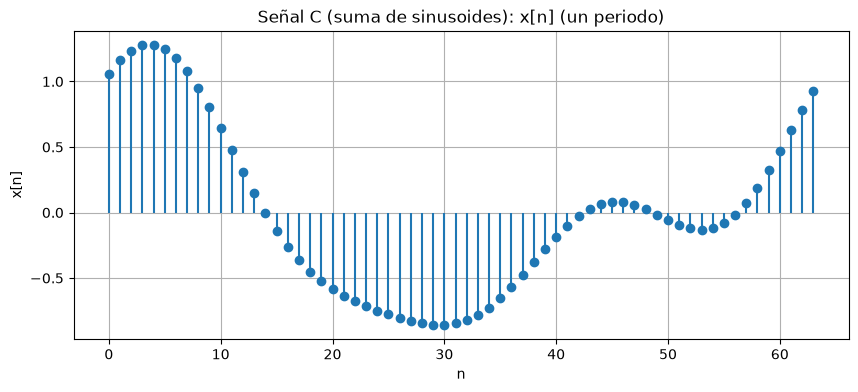

In [91]:
plt.figure()
plt.stem(n3, xC, basefmt=" ")
plt.title("Señal C (suma de sinusoides): x[n] (un periodo)")
plt.xlabel("n"); plt.ylabel("x[n]")
plt.grid(True)
plt.show()

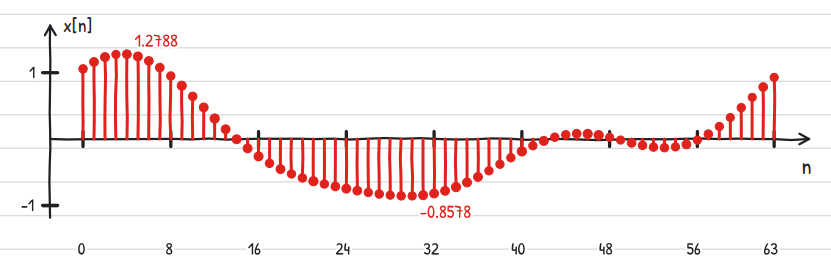

### Inciso b) Espectro de magnitud $|X_C[k]|$

Calculamos los coeficientes con `dfs` (producto interno de $x_C[n]$ con $e^{-j\frac{2\pi}{N}kn}$) y graficamos su magnitud.
Se verifica el teorema de Parseval.

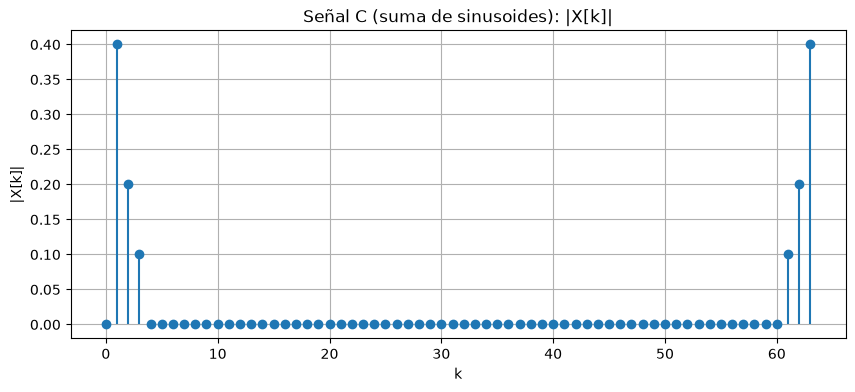

Parseval: 0.42000000000000004 vs 0.42000000000000004


In [92]:
XC = dfs(xC)

plt.figure()
plt.stem(k3, np.abs(XC), basefmt=" ")
plt.title("Señal C (suma de sinusoides): |X[k]|")
plt.xlabel("k"); plt.ylabel("|X[k]|")
plt.grid(True)
plt.show()

print("Parseval:", np.sum(np.abs(XC)**2), "vs", np.mean(xC**2))

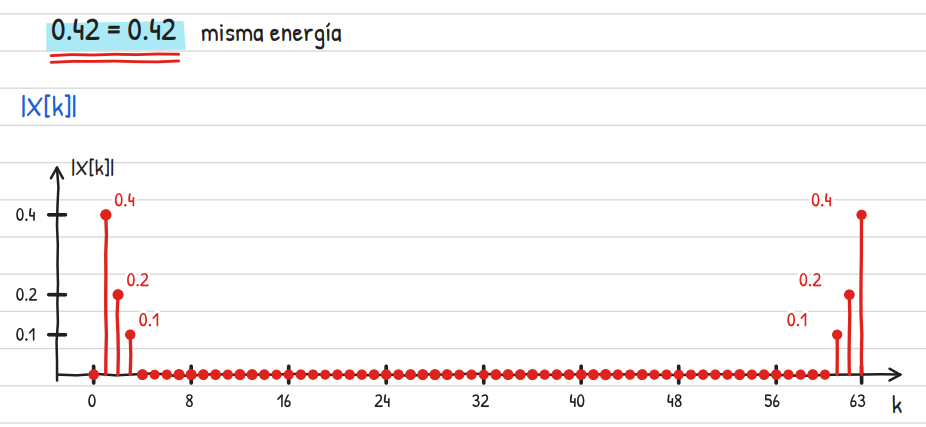

### Inciso c) Espectro de fase $\angle X_C[k]$

Usamos `fase()`: es `np.angle(X)` pero con 0 donde $|X[k]| \approx 0$, porque ahí el ángulo no está definido y solo se vería ruido. En esta señal es especialmente importante, porque casi todos los coeficientes valen ~0.

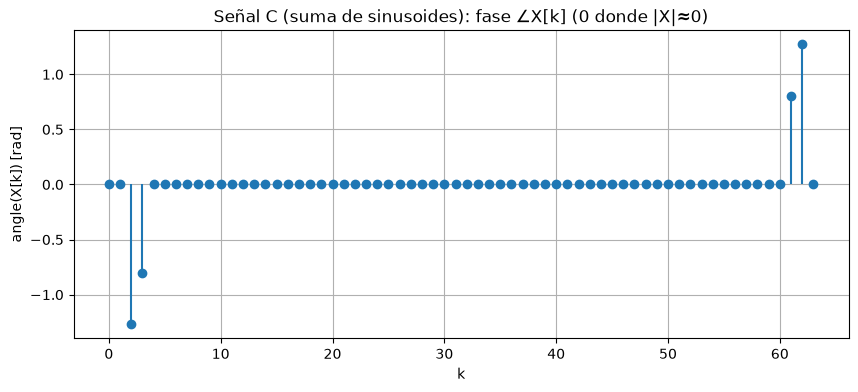

In [93]:
plt.figure()
plt.stem(k3, fase(XC), basefmt=" ")
plt.title("Señal C (suma de sinusoides): fase ∠X[k] (0 donde |X|≈0)")
plt.xlabel("k"); plt.ylabel("angle(X[k]) [rad]")
plt.grid(True)
plt.show()

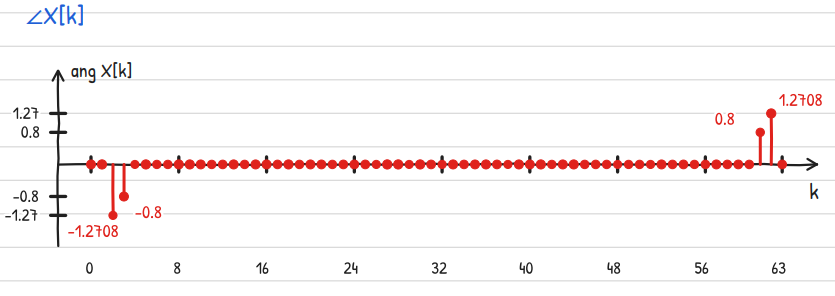

### Inciso d) Reconstrucción $\hat{x}_C[n]$ vs. $x_C[n]$

Reconstruimos la señal con `idfs` (síntesis) y la comparamos con la original sobre un periodo. Se grafica `np.real(x_hat)` porque la parte imaginaria es solo ruido numérico.

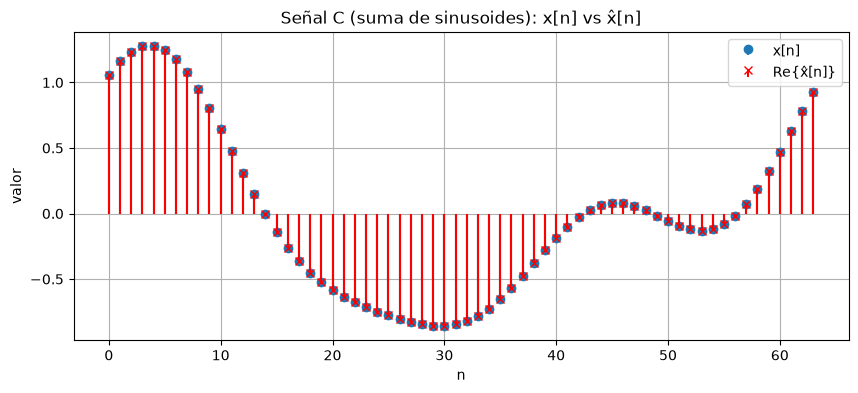

In [94]:
xC_hat = idfs(XC)

plt.figure()
plt.stem(n3, np.real(xC), basefmt=" ", markerfmt="o", label="x[n]")
plt.stem(n3, np.real(xC_hat), basefmt=" ", markerfmt="x", linefmt="r-", label="Re{x̂[n]}")
plt.title("Señal C (suma de sinusoides): x[n] vs x̂[n]")
plt.xlabel("n"); plt.ylabel("valor")
plt.grid(True)
plt.legend()
plt.show()

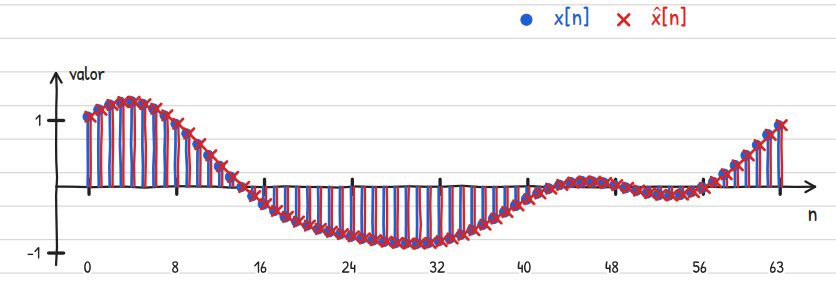

### Inciso e) Error de reconstrucción (RMSE)

Error cuadrático medio sobre un periodo:

$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

Se imprime la parte imaginaria máxima de $\hat{x}[n]$ (`np.max(np.abs(np.imag(xC_hat)))`): como $x_C[n]$ es real, en teoría vale 0 y lo que queda es redondeo numérico (del orden de $10^{-15}$ a $10^{-14}$).

In [95]:
eC = rmse(xC, xC_hat)
print(f"Señal C: N={N3}, RMSE = {eC:.6e}")
print(f"Máx |Im{{x̂[n]}}| = {np.max(np.abs(np.imag(xC_hat))):.3e}  (se tomó la parte real)")

Señal C: N=64, RMSE = 7.338548e-15
Máx |Im{x̂[n]}| = 1.450e-14  (se tomó la parte real)


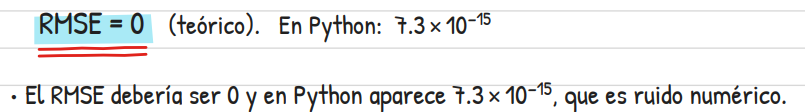

*Nota: En el PDF de la tarea se encuentran las resoluciones completas a mano, aqui solo se ponen los resultados y gráficas obtenidas para demostrar que coincide lo manual con lo que arroja Python*

## Short reflection (write your answers here)

For each signal:

- How many coefficients (roughly) are “dominant” in magnitude?
- Does the phase look structured or noisy? Why?
- If you keep only the largest M coefficients (optional extension), what happens in reconstruction?

*(Write 2–4 sentences per signal.)

###Señal A

**1. ¿Cuántos coeficientes son "dominantes" en magnitud?**

Solo los armónicos impares tienen valores diferentes de cero ($k=1,3,5,\dots,15$) y su tamaño disminuye poco a poco, aproximadamente como $\frac{1}{k}$. Los más grandes son $k=1$ y $k=15$, con $0.6407$, pero $k=3$, $5$ y $7$ también tienen valores importantes ($0.2250$, $0.1503$ y $0.1274$). Por eso, no hay pocos armónicos que sean mucho más importantes que los demás y se necesitan los $8$ armónicos impares para representar bien los cambios de la onda.

**2. ¿La fase se ve estructurada o ruidosa? ¿Por qué?**

La fase sigue un patrón ordenado es decir es estructurada. Aumenta de forma lineal con $k$, según $\angle X[k] = \frac{\pi k}{16} - \frac{\pi}{2}$, y va de $-1.374$ a $+1.374$ rad. Esto se debe a que la señal es simétrica y sus coeficientes tienen una parte real constante. Los valores pares de $k$ tienen magnitud $0$, por lo que su fase no es importante.

**3. Si se conservan solo los M coeficientes más grandes, ¿qué pasa en la reconstrucción?**

Con pocos coeficientes, la señal reconstruida tiene pequeñas oscilaciones cerca de los cambios de la onda cuadrada, lo que se conoce como fenómeno de Gibbs. El error va disminuyendo poco a poco al usar más coeficientes. La señal se parece realmente a la original cuando $M$ es grande. Con los $16$ coeficientes, la reconstrucción es prácticamente exacta, con un RMSE de aproximadamente $3.142\times10^{-15}$, es decir $0$

###Señal B

**1. ¿Cuántos coeficientes son "dominantes" en magnitud?**

Solo los armónicos impares tienen valores diferentes de cero ($k=1,3,5,\dots,15$) y su tamaño disminuye muy rápido, aproximadamente como $\frac{1}{k^2}$. El más grande es $k=1$ y su simétrico $k=31$ con $0.4066$; el siguiente, $k=3$, ya baja a $0.0464$ y todos los demás son menores a $0.02$. Por eso, hay muy pocos coeficientes dominantes, con $k=1$ y $k=31$ ya se tiene más del $95\%$ de la energía de la señal.

**2. ¿La fase se ve estructurada o ruidosa? ¿Por qué?**

La fase es estructurada, los coeficientes con $k$ impar son números reales y negativos, por lo que su fase es $\pi$ o $-\pi$, que es el mismo ángulo, y esto se debe a que la señal es simétrica. En la gráfica de Python los valores alternan entre $+\pi$ y $-\pi$ porque la parte imaginaria es un residuo muy pequeño ($\approx 10^{-17}$) que cambia de signo, pero en realidad es el mismo ángulo. Los valores pares de $k$ tienen magnitud $0$, por lo que su fase no es importante.

**3. Si se conservan solo los M coeficientes más grandes, ¿qué pasa en la reconstrucción?**

Con pocos coeficientes, la señal reconstruida se sigue pareciendo a la triangular, pero con el pico y el valle un poco redondeados. Con $M=2$, $k=1$ y $k=31$ el RMSE es aprox. $0.073$ y con $M=4$ baja a $0.032$, o sea que el error va disminuyendo al usar más coeficientes. Con los $32$ coeficientes, la reconstrucción es prácticamente exacta, con un RMSE de aproximadamente $2.795\times10^{-15}$, o sea  que es $0$.

###Señal C

**1. ¿Cuántos coeficientes son "dominantes" en magnitud?**

Solo hay $6$ coeficientes diferentes de cero: $k=1, 2$ y $3$, y sus simétricos $k=63, 62$ y $61$. Los más grandes son $k=1$ y $k=63$, con $0.4$; después $k=2$ y $k=62$ con $0.2$, y $k=3$ y $k=61$ con $0.1$, que es justo la mitad de la amplitud de cada sinusoide, con $0.8$, $0.4$ y $0.2$. Los demás valen $0$, por lo que se necesitan estos $6$ para representar la señal, y los más importantes serian $k=1$ y $k=63$.

**2. ¿La fase se ve estructurada o ruidosa? ¿Por qué?**

La fase es estructurada, cada coeficiente tiene la fase de su sinusoide, $\angle X[1] = 0$, $\angle X[2] = 0.3 - \frac{\pi}{2} \approx -1.2708$ y $\angle X[3] = -0.8$ rad. Los simétricos tienen el mismo valor con signo contrario porque la señal es real. Los demás valores de $k$ tienen magnitud $0$, o sea que su fase no es importante.

**3. Si se conservan solo los M coeficientes más grandes, ¿qué pasa en la reconstrucción?**

Con $M=2$, $k=1$ y $k=63$, solo se reconstruye la sinusoide más grande y el RMSE es aproximadamente $0.316$. Con $M=4$ se agregan $k=2$ y $k=62$ y el error baja a $0.141$. Con $M=6$ la reconstrucción ya es exacta porque esos son los únicos coeficientes diferentes de cero.